# Primer circuito cuántico

Este notebook construye, ejecuta y explica un circuito cuántico real con Polypus: el estado de Bell, el ejemplo más citado en toda la computación cuántica.

## Construir el circuito

Un circuito de Polypus se construye encadenando métodos sobre `Circuit`, como se vio en [`00a`](00a_programacion_basica.ipynb):

- `Circuit(2)`: un circuito con 2 qubits, numerados 0 y 1.
- `.h(0)`: pone el qubit 0 en superposición.
- `.cx(0, 1)`: aplica CX con el qubit 0 como control y el 1 como objetivo.
- `.measure_all()`: mide todos los qubits al final.

In [1]:
import polypus

bell = polypus.Circuit(2).h(0).cx(0, 1).measure_all()

Este circuito, H seguido de CX sobre un par de qubits inicializados en `|00⟩`, es el llamado **estado de Bell**, o **par de Bell**: la construcción mínima que produce entrelazamiento, y reaparece más adelante en la serie, por ejemplo, en [`04a_teletransporte.ipynb`](04a_teletransporte.ipynb).

## Ejecutar el circuito

`run_quantum_circuit` ejecuta un circuito y devuelve su resultado. Recibe el circuito como primer argumento posicional, en este caso `bell`, y dos argumentos con nombre principales:

- `shots`: número de veces que se ejecuta y mide el circuito. Con más shots, la distribución de frecuencias se acerca más a la probabilidad real, como se vio en [`00b`](00b_intuicion_cuantica.ipynb).
- `infrastructure`: dónde se ejecuta. `"local"` usa un simulador en el propio ordenador; el resto de opciones se explican en [`03a_ejecucion_local.ipynb`](03a_ejecucion_local.ipynb).

In [2]:
result = polypus.run_quantum_circuit(bell, shots=1000, infrastructure="local")
print(result.counts)

[{'00': 488, '11': 512}]


El resultado se parece a `[{'11': ~500, '00': ~500}]`, aunque no exactamente esos números: es aleatoriedad real. `result.counts` viene envuelto en una **lista** de un único elemento. El motivo, y qué cambia al repartir la ejecución entre varias QPUs, se explica en [`03a_ejecucion_local.ipynb`](03a_ejecucion_local.ipynb).

Para quedarse con el diccionario, se accede a la posición 0:

In [3]:
counts = result.counts[0]
print(counts)

{'00': 488, '11': 512}


## El resultado sorpresa

En `counts` solo aparecen dos claves, `'00'` y `'11'`, nunca `'01'` ni `'10'`. Cada qubit por separado sigue pareciendo aleatorio, con más o menos la mitad de los resultados en 0 y la mitad en 1, pero **los dos qubits siempre coinciden**: esto es entrelazamiento, tal como se anticipó en [`00b`](00b_intuicion_cuantica.ipynb). Medir uno de los dos qubits determina instantáneamente el resultado del otro.

## Visualizar el resultado

Un histograma ayuda a ver la distribución de un vistazo. No hace falta conocer matplotlib a fondo para esto, basta con esta receta:

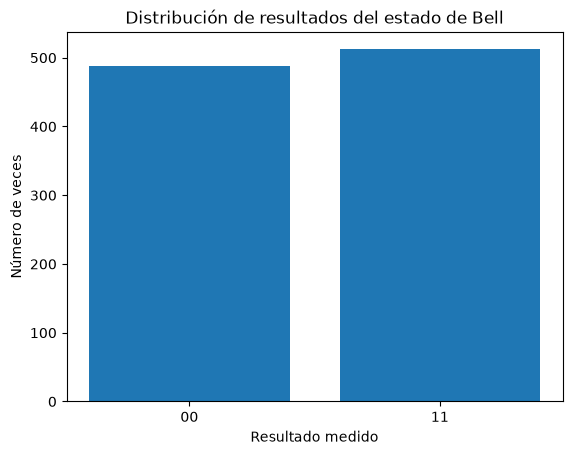

In [4]:
import matplotlib.pyplot as plt

plt.bar(counts.keys(), counts.values())
plt.xlabel("Resultado medido")
plt.ylabel("Número de veces")
plt.title("Distribución de resultados del estado de Bell")
plt.show()

## Resumen

En este notebook se ha construido un circuito encadenando métodos, se ha ejecutado con `run_quantum_circuit`, y se ha leído e interpretado su resultado: dos qubits que, tras una puerta H y una CX, quedan entrelazados, un fenómeno sin equivalente clásico.

La siguiente sección profundiza en las puertas disponibles y en cómo Polypus interopera con Qiskit y con OpenQASM.

## Siguiente paso

Continúa con: [`02a_puertas_y_construccion.ipynb`](02a_puertas_y_construccion.ipynb).